# 10b · Polarization: a splitter and a splitter-rotator

Everything so far launched one polarization (TE0). Real links carry **two** —
TE0 and TM0 — and managing them is its own discipline. This notebook simulates
two classic polarization-handling devices, both taken **straight from
gdsfactory**, with multi-mode S-parameters (`spec.modes=(1, 2)`):

1. a **polarization beam splitter (PBS)** built from a directional coupler —
   TM couples across the gap much faster than TE, so one length can separate
   the two;
2. gdsfactory's **`polarization_splitter_rotator` (PSR)** — designed to take
   TM0 in and route it out as TE0 on a separate port (we measure how close
   the *stock* cell gets in this technology, on both engines).

Both devices were recorded on **two multi-mode engines** — Lumerical (licensed
local workstation) and **tidy3d** (cloud) — from the identical
`(component, technology, spec)`, so every number below is cross-checked and
the notebook reproduces for free. beamz v1 is TE-only — polarization work
needs tidy3d or Lumerical (see `07`).

In [1]:
from pathlib import Path

import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.grid import resolve_index
from gds_fdtd.layout.gdsfactory import from_gdsfactory
from gds_fdtd.modes import waveguide_mode
from gds_fdtd.plotting import plot_component, plot_mode
from gds_fdtd.smatrix import SMatrix
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


REC = _find("examples/10_cookbook/recorded")
tech = Technology.from_yaml(_find("examples/tech.yaml"))
gf.gpdk.PDK.activate()

## 1 · The two players: TE0 and TM0

The strip waveguide's first two modes. **TE0** (E mostly in-plane, `Ex`) is
tightly confined; **TM0** (E mostly vertical, `Ez`… shown via its dominant
in-plane pattern) sits at lower effective index and leaks further into the
cladding — which is exactly why it couples across gaps faster. Solved offline
with the free local mode solver.

10:44:18 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

10:44:20 PDT WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'. Alternatively, you can install 
             the package 'tidy3d-extras' using 'pip install "tidy3d"' and set   
             'config.simulation.use_local_subpixel=True'.                       

             WARNING: Permittivity spatial data array does not fully cover the  
             requested region.                                                  

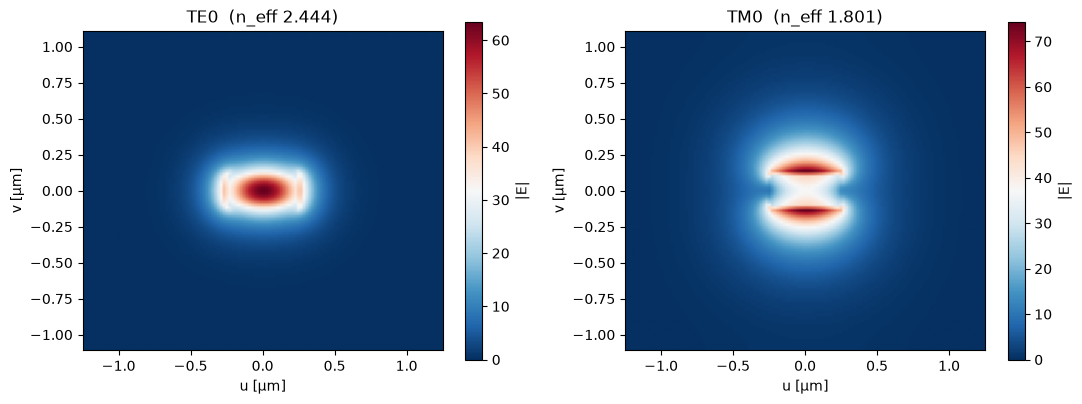

TE0 n_eff = 2.4441   TM0 n_eff = 1.8011 (lower -> less confined -> couples faster)


In [2]:
n_core = resolve_index(tech.device[0].material, 1.55).real
n_clad = resolve_index(tech.superstrate.material, 1.55).real
modes = waveguide_mode(0.5, 0.22, n_core, n_clad, 1.55, n_modes=2)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_mode(modes[0], ax=ax[0])
ax[0].set_title(f"TE0  (n_eff {modes[0].n_eff.real:.3f})")
plot_mode(modes[1], ax=ax[1])
ax[1].set_title(f"TM0  (n_eff {modes[1].n_eff.real:.3f})")
fig.tight_layout()
plt.show()
print(
    f"TE0 n_eff = {modes[0].n_eff.real:.4f}   TM0 n_eff = {modes[1].n_eff.real:.4f} "
    "(lower -> less confined -> couples faster)"
)

## 2 · PBS — a directional coupler that splits polarizations

One coupler, two very different **beat lengths**: the loosely-confined TM0
transfers across the 0.2 µm gap several times faster than TE0. Choosing the
coupler length at TM's *cross maximum* (~6 µm here) makes one device route
the polarizations to different ports. (Pick it badly — say 12 µm — and TM
beats across *and back*; we measured exactly that before settling on 6 µm.)
Ports: `o1` (in, bottom-left), `o4` (through, bottom-right), `o3` (cross,
top-right).

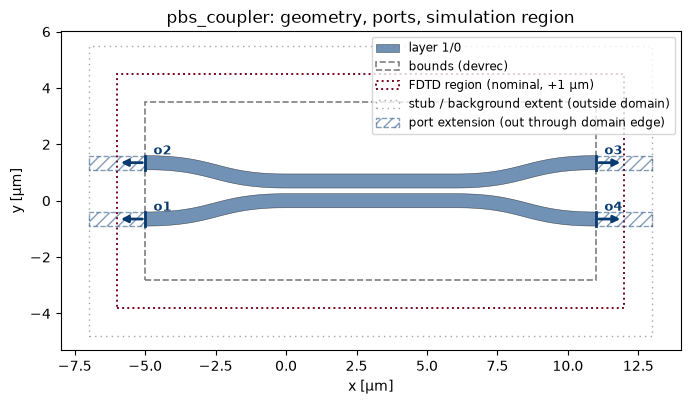

In [3]:
pbs = from_gdsfactory(gf.components.coupler(length=6.0, gap=0.2, dx=5.0, dy=2.0), tech)
pbs.name = "pbs_coupler"
plot_component(pbs, spec=SimulationSpec())
plt.show()

The recorded multi-mode S-matrices (`modes=(1, 2)`; mode 1 = TE0, mode 2 =
TM0) from **both engines** on the identical job. Solid = through arm (`o4`),
dashed = cross arm (`o3`); color = engine. The two engines tell the same
story: TE stays, TM crosses.

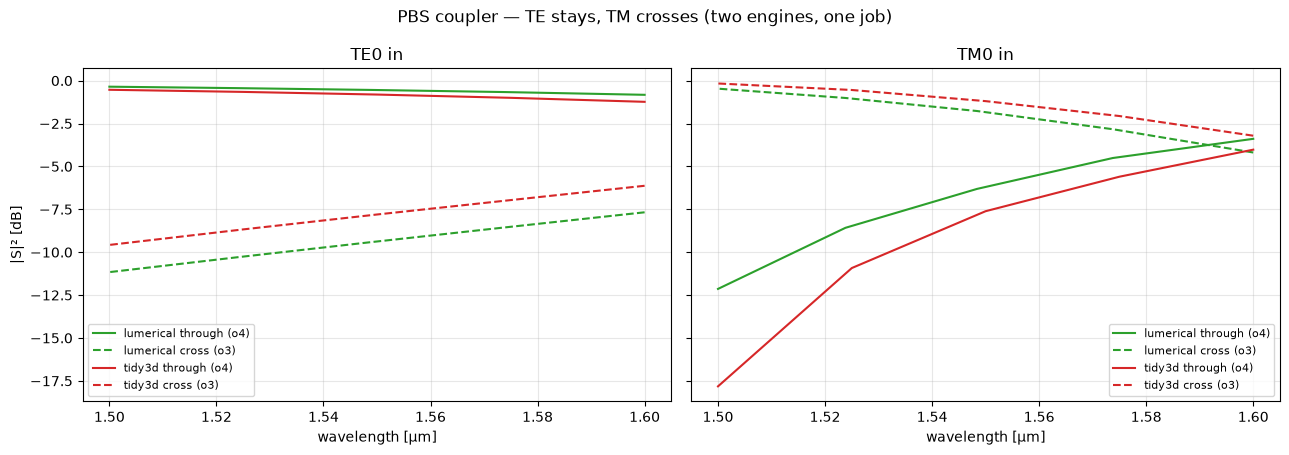

lumerical  TE0 @1.55: through -0.54 · cross -9.43 dB  -> exits through o4
lumerical  TM0 @1.55: through -6.31 · cross -1.77 dB  -> exits cross o3
tidy3d     TE0 @1.55: through -0.81 · cross -7.80 dB  -> exits through o4
tidy3d     TM0 @1.55: through -7.61 · cross -1.20 dB  -> exits cross o3


In [4]:
pbs_sm = {
    "lumerical": SMatrix.from_npz(str(REC / "pbs_coupler_lumerical.npz")),
    "tidy3d": SMatrix.from_npz(str(REC / "pbs_coupler_tidy3d.npz")),
}
ecolor = {"lumerical": "tab:green", "tidy3d": "tab:red"}
fig, axs = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, (pol, m) in zip(axs, (("TE", 1), ("TM", 2)), strict=True):
    for eng, sm in pbs_sm.items():
        ax.plot(
            sm.wavelength_um,
            sm.magnitude_db(out=4, in_=1, mode_out=m, mode_in=m),
            "-",
            color=ecolor[eng],
            label=f"{eng} through (o4)",
        )
        ax.plot(
            sm.wavelength_um,
            sm.magnitude_db(out=3, in_=1, mode_out=m, mode_in=m),
            "--",
            color=ecolor[eng],
            label=f"{eng} cross (o3)",
        )
    ax.set_title(f"{pol}0 in")
    ax.set_xlabel("wavelength [µm]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axs[0].set_ylabel("|S|² [dB]")
fig.suptitle("PBS coupler — TE stays, TM crosses (two engines, one job)")
fig.tight_layout()
plt.show()

for eng, sm in pbs_sm.items():
    i0 = int(np.argmin(np.abs(sm.wavelength_um - 1.55)))
    for pol, m in (("TE", 1), ("TM", 2)):
        thru = float(sm.magnitude_db(out=4, in_=1, mode_out=m, mode_in=m)[i0])
        cross = float(sm.magnitude_db(out=3, in_=1, mode_out=m, mode_in=m)[i0])
        keep = "through o4" if thru > cross else "cross o3"
        print(
            f"{eng:10s} {pol}0 @1.55: through {thru:+.2f} · cross {cross:+.2f} dB  -> exits {keep}"
        )

…and the same physics as **fields**: |E|² with a TE0 excitation (top row)
versus a TM0 excitation (bottom row), from each engine. Watch the TM field hop
across the gap while the TE field stays in its arm — on both engines.

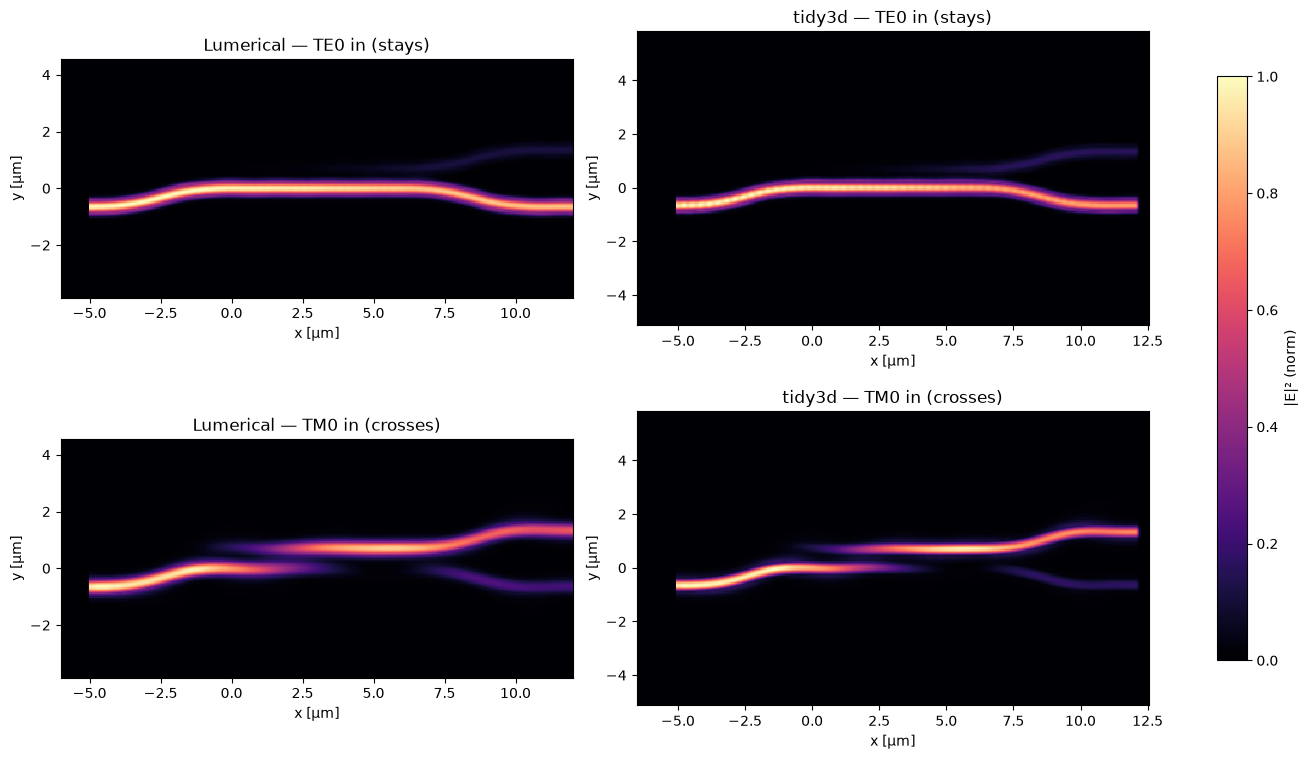

In [5]:
def _field_panel(ax, npz, title):
    d = np.load(npz)
    im = ax.pcolormesh(
        d["x"], d["y"], (d["E2"] / d["E2"].max()).T, shading="nearest", cmap="magma", vmin=0, vmax=1
    )
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")
    return im


fig, axes = plt.subplots(2, 2, figsize=(13, 7.6), constrained_layout=True)
_field_panel(axes[0, 0], REC / "pbs_coupler_field_TE_in.npz", "Lumerical — TE0 in (stays)")
_field_panel(axes[1, 0], REC / "pbs_coupler_field_TM_in.npz", "Lumerical — TM0 in (crosses)")
_field_panel(axes[0, 1], REC / "pbs_coupler_field_TE_in_tidy3d.npz", "tidy3d — TE0 in (stays)")
im = _field_panel(
    axes[1, 1], REC / "pbs_coupler_field_TM_in_tidy3d.npz", "tidy3d — TM0 in (crosses)"
)
fig.colorbar(im, ax=axes, label="|E|² (norm)", shrink=0.8)
plt.show()

## 3 · PSR — gdsfactory's polarization splitter-rotator

The PBS separates polarizations but both stay what they were. A **PSR** goes
further: TM0 in → **TE0 out**, so downstream circuitry only ever sees TE.
gdsfactory ships a taper + asymmetric-coupler design
(`gf.components.polarization_splitter_rotator`, ~71 µm): the widening taper
adiabatically converts TM0 → TE1, and the narrow coupler arm peels TE1 off as
its TE0.

**One physics prerequisite:** TM0→TE1 rotation only happens when the
**vertical symmetry is broken** — this is an **air-clad** SOI design. We
simulate it with an air superstrate (`nk: 1.0`); a sidebar below shows what
happens if you bury the same layout in symmetric oxide.

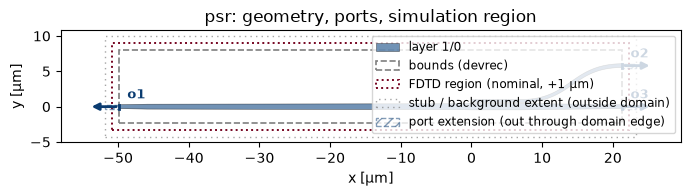

In [6]:
import copy  # noqa: E402

air_tech = copy.deepcopy(tech.to_solver_dict())
air_tech["superstrate"][0]["material"] = {"nk": 1.0}  # air top-cladding
psr = from_gdsfactory(gf.components.polarization_splitter_rotator(), air_tech)
psr.name = "psr"
plot_component(psr, spec=SimulationSpec())
plt.show()

The recorded multi-mode S-matrices (air-clad) from **both engines**. The two
questions that define a PSR: where does TE0 go (it should pass through on the
bus, untouched), and where does TM0 go (it should exit the other arm —
*as TE0*)?

In [7]:
psr_sm = {
    "lumerical": SMatrix.from_npz(str(REC / "psr_lumerical.npz")),
    "tidy3d": SMatrix.from_npz(str(REC / "psr_tidy3d.npz")),
}
print(f"{'engine':10s} {'in':6s} {'out':12s} {'@1.55 [dB]':>12s}")
for eng, sm2 in psr_sm.items():
    i0 = int(np.argmin(np.abs(sm2.wavelength_um - 1.55)))
    for pol_in, m_in in (("TE0", 1), ("TM0", 2)):
        rows = []
        for o, m_out, label in (
            (2, 1, "o2 as TE0"),
            (2, 2, "o2 as TM0"),
            (3, 1, "o3 as TE0"),
            (3, 2, "o3 as TM0"),
        ):
            v = float(sm2.magnitude_db(out=o, in_=1, mode_out=m_out, mode_in=m_in)[i0])
            rows.append((label, v))
        best = max(v for _, v in rows)
        for label, v in rows:
            mark = "  <-- main path" if v == best else ""
            print(f"{eng:10s} {pol_in:6s} {label:12s} {v:>12.2f}{mark}")

engine     in     out            @1.55 [dB]
lumerical  TE0    o2 as TE0          -56.54
lumerical  TE0    o2 as TM0          -52.17
lumerical  TE0    o3 as TE0           -0.01  <-- main path
lumerical  TE0    o3 as TM0          -32.06
lumerical  TM0    o2 as TE0          -21.34
lumerical  TM0    o2 as TM0          -19.08
lumerical  TM0    o3 as TE0          -31.97
lumerical  TM0    o3 as TM0           -8.48  <-- main path
tidy3d     TE0    o2 as TE0          -50.88
tidy3d     TE0    o2 as TM0          -38.88
tidy3d     TE0    o3 as TE0           -0.01  <-- main path
tidy3d     TE0    o3 as TM0          -50.98
tidy3d     TM0    o2 as TE0          -14.72
tidy3d     TM0    o2 as TM0          -24.97
tidy3d     TM0    o3 as TE0          -51.65
tidy3d     TM0    o3 as TM0           -3.14  <-- main path


**Reading the table honestly.** The TE0 row is perfect — both engines agree
to a hundredth of a dB that TE0 sails through on the bus (`o3`, ≈ 0 dB),
untouched. The TM0 row is the interesting one: conversion happens
(`o2 as TE0` sits ~6 dB above the symmetric-oxide sidebar below) but it is
**partial** — much of the TM power radiates in the taper, and the two engines,
while agreeing qualitatively, differ on the weak converted paths (hybrid-mode
conversion is mesh-sensitive at this resolution). Two lessons in one device:
the *stock* gdsfactory cell needs dimension re-optimization for this exact
stack before it is a production PSR, and weak multi-mode paths are exactly
where you cross-check a second engine (the `06` lesson, polarized edition).

The two excitations as fields, from each engine — TE0 undisturbed on the bus,
TM0 interacting strongly in the taper (partially converting, partially
radiating):

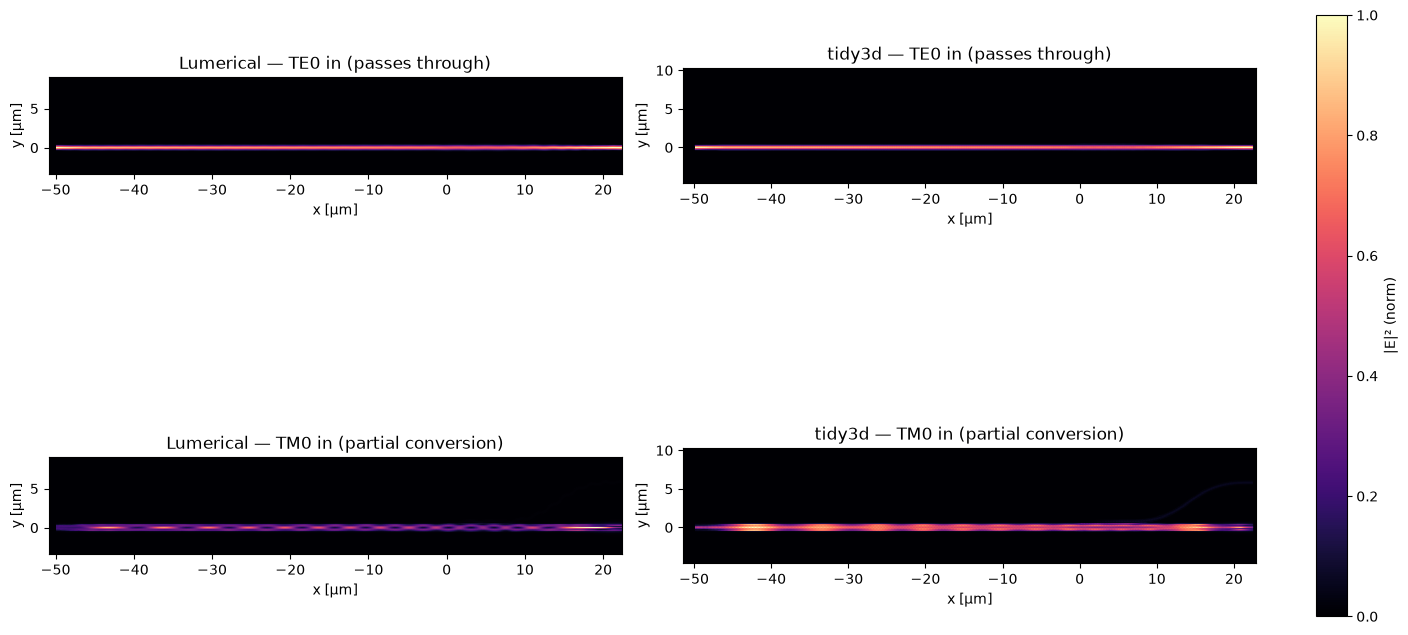

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7.6), constrained_layout=True)
_field_panel(axes[0, 0], REC / "psr_field_TE_in.npz", "Lumerical — TE0 in (passes through)")
_field_panel(axes[1, 0], REC / "psr_field_TM_in.npz", "Lumerical — TM0 in (partial conversion)")
_field_panel(axes[0, 1], REC / "psr_field_TE_in_tidy3d.npz", "tidy3d — TE0 in (passes through)")
im = _field_panel(
    axes[1, 1], REC / "psr_field_TM_in_tidy3d.npz", "tidy3d — TM0 in (partial conversion)"
)
fig.colorbar(im, ax=axes, label="|E|² (norm)", shrink=0.8)
plt.show()

### Sidebar: why the cladding matters (a recorded negative result)

We first ran the *identical layout* buried in **symmetric oxide** cladding.
The result is a beautiful non-event — TM0 sails through **unconverted**:

In [9]:
sym = SMatrix.from_npz(str(REC / "psr_symclad_lumerical.npz"))
i0 = int(np.argmin(np.abs(sym.wavelength_um - 1.55)))
te_thru = float(sym.magnitude_db(out=3, in_=1, mode_out=1, mode_in=1)[i0])
tm_stay = float(sym.magnitude_db(out=3, in_=1, mode_out=2, mode_in=2)[i0])
tm_conv = float(sym.magnitude_db(out=2, in_=1, mode_out=1, mode_in=2)[i0])
print(
    f"symmetric-oxide cladding @1.55:  TE0 through {te_thru:+.2f} dB · "
    f"TM0 stays TM0 {tm_stay:+.2f} dB · converted TE0 only {tm_conv:+.2f} dB"
)

symmetric-oxide cladding @1.55:  TE0 through -0.00 dB · TM0 stays TM0 -0.59 dB · converted TE0 only -20.40 dB


With oxide above *and* below, the structure has a vertical mirror symmetry;
TM0 and TE1 then belong to opposite symmetry classes and **cannot couple**,
no matter how adiabatic the taper. Breaking that symmetry (air top-cladding)
is what unlocks the rotation — a fact the S-matrix states more bluntly than
any textbook.

## Recap

- TE0/TM0 have different confinement (`waveguide_mode` shows it offline), and
  that asymmetry powers polarization devices.
- A stock directional coupler at TM's cross-maximum length acts as a **PBS** —
  and a mis-chosen length lets TM beat across *and back* (we measured both).
- gdsfactory's **PSR**: the TE path is perfect (−0.01 dB, both engines
  agreeing exactly), and TM0→TE0 conversion happens **only** with the vertical
  symmetry broken (air-clad) — but the *stock* dimensions convert only
  partially in this stack, and the weak converted paths are where the two
  engines differ. Re-optimize the cell for your stack, and cross-validate.
  All three recordings (air-clad × 2 engines + the symmetric-oxide negative
  control) are committed.
- Polarization work needs a multi-mode engine (tidy3d or Lumerical);
  beamz v1 is TE-only. Recorded artifacts + recipe in `recorded/PROVENANCE.md`.